# SUPR right lower leg + foot — what the parameters actually do

The same playground as `playground.ipynb`, but for the shank and foot instead of the foot
alone.

One thing is different and it matters. There is no standalone SUPR model for the lower leg, so
this notebook loads the **full-body** model and shows only the vertices belonging to this
cut-out:

```text
output/supr_explorer/supr_neutral_right_lower_leg_with_foot.ply
```

That PLY is a subset of the body mesh, so the notebook looks its vertices up in the body and
keeps the indices. Posing and betas are therefore real body parameters — the whole body moves
and you are watching one piece of it. A PLY on its own has no pose or shape parameters at all,
which is why it cannot simply be loaded and posed.

Because the cut-out now reaches past the ankle, the foot and toe joints are included and the
ankle is no longer an open rim — only the knee is.

Units are **millimetres** throughout. The full-body model is in metres, so that conversion is
exact rather than an anchor we chose.

## 1 — Setup

In [1]:
import os, sys
os.environ["CUDA_VISIBLE_DEVICES"] = "1"          # pick any free GPU

REPO = "/storage/Abhinay/Shell_Gaussian/baselines/SUPR"
if REPO not in sys.path:
    sys.path.insert(0, REPO)

import numpy as np, torch
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from matplotlib.collections import PolyCollection
from scipy.spatial import cKDTree
import trimesh
from trimesh.intersections import mesh_plane
from supr.pytorch.supr import SUPR

NUM_BETAS = 100      # the file holds 400; 100 is plenty
UNIT_MM   = 1000.0   # the full-body model is in metres -- exact, not an anchor
DEVICE    = "cuda" if torch.cuda.is_available() else "cpu"

BODY    = f"{REPO}/data/supr_neutral.npy"
LEG_PLY = f"{REPO}/output/supr_explorer/supr_neutral_right_lower_leg_with_foot.ply"

model = SUPR(BODY, num_betas=NUM_BETAS)

# The saved cut-out is a subset of the body mesh, so an exact nearest-vertex lookup
# recovers which body vertices it is. That is what lets us pose the whole body and
# draw only this piece -- a PLY on its own has no pose or shape parameters.
_cut   = trimesh.load(LEG_PLY, process=False)
_cut_v = np.asarray(_cut.vertices, np.float64)
FACES  = np.asarray(_cut.faces, np.int64)              # already indexed 0..N-1

_body_v = np.asarray(np.load(BODY, allow_pickle=True).item()["v_template"], np.float64)
_gap, LEG_VERTS = cKDTree(_body_v).query(_cut_v)
if _gap.max() > 1e-6 or len(np.unique(LEG_VERTS)) != len(LEG_VERTS):
    raise RuntimeError(f"{LEG_PLY} is not a clean subset of {BODY} "
                       f"(worst match {_gap.max():.2e} m)")

def _boundary_rims(faces, vertices):
    """Open edges grouped into rings, ordered top first.

    The leg-only cut has two rings (knee and ankle). Once the foot is attached the
    ankle is no longer an edge, so only the knee ring remains."""
    e = np.sort(np.concatenate([faces[:, [0, 1]], faces[:, [1, 2]], faces[:, [2, 0]]]), axis=1)
    uniq, count = np.unique(e, axis=0, return_counts=True)
    border = uniq[count == 1]
    if not len(border):
        return []
    adj = {}
    for a, b in border:
        adj.setdefault(int(a), set()).add(int(b))
        adj.setdefault(int(b), set()).add(int(a))
    seen, rings = set(), []
    for start in adj:
        if start in seen:
            continue
        stack, ring = [start], []
        while stack:
            v = stack.pop()
            if v in seen:
                continue
            seen.add(v); ring.append(v)
            stack.extend(adj[v] - seen)
        rings.append(np.asarray(sorted(ring), dtype=np.int64))
    rings.sort(key=lambda r: -vertices[r, 1].mean())   # +Y is up, so the knee comes first
    return rings

_rings = _boundary_rims(FACES, _cut_v)
RIM_COLOURS = ("#C0442A", "#2E8B57", "#B08968")
RIM_NAMES   = ("knee rim", "ankle rim", "rim 3")
RIMS = [(r, RIM_COLOURS[k % 3], RIM_NAMES[k % 3]) for k, r in enumerate(_rings)]

print(f"device {DEVICE} | body: {model.num_joints} joints, {model.num_pose} pose numbers, "
      f"{model.num_verts} vertices")
print(f"cut-out: {os.path.basename(LEG_PLY)}")
print(f"         {len(LEG_VERTS)} vertices, {len(FACES)} triangles, "
      f"matched to the body exactly (worst gap {_gap.max():.1e} m)")
print(f"         open rings: " + (", ".join(f"{n} ({len(r)} verts)" for r, _, n in RIMS)
                                  or "none -- closed surface"))
print("SUPR only publishes male models, so this is the one body we have.")

device cuda | body: 75 joints, 225 pose numbers, 10475 vertices
cut-out: supr_neutral_right_lower_leg_with_foot.ply
         453 vertices, 887 triangles, matched to the body exactly (worst gap 0.0e+00 m)
         open rings: knee rim (17 verts)
SUPR only publishes male models, so this is the one body we have.


## 2 — The kit

`leg(knee_pitch=45)` poses the body and hands back the shank. `report` prints it in mm,
`show` draws flat views, `make_view` gives you a rotatable 3D one.

Everything is in degrees going in and millimetres coming out.

In [2]:
# right-side joints of the full body. The foot and toes are included because the
# cut-out now reaches past the ankle.
JOINTS = {"hip": 2, "knee": 5, "ankle": 8, "foot": 11,
          "big_toe": 65, "big_toe_tip": 66, "toe2": 67, "toe2_tip": 68,
          "toe3": 69, "toe3_tip": 70, "toe4": 71, "toe4_tip": 72,
          "little_toe": 73, "little_toe_tip": 74}
TOE_BASES = ("big_toe", "toe2", "toe3", "toe4", "little_toe")
AXES = {"pitch":0, "yaw":1, "roll":2}
AXIS_MEANING = {"pitch":"bend forward/back -- knee (+) folds the heel back",
                "yaw":  "twist about the long axis",
                "roll": "swing sideways -- (+) moves the shank outward"}
DESC = {"hip": "swings the whole leg; the shank moves but barely changes shape",
        "knee": "THE shank joint -- most of the calf follows it",
        "ankle": "rotates the foot and the skin just above it",
        "foot": "the ball of the foot -- bends the forefoot",
        "big_toe": "big toe knuckle", "toe2": "2nd toe knuckle",
        "toe3": "3rd toe knuckle", "toe4": "4th toe knuckle",
        "little_toe": "little toe knuckle"}

RECIPES = {
    "standing":                    {},
    "knee bent 30":                {"knee_pitch": 30},
    "knee bent 90 (sitting)":      {"knee_pitch": 90},
    "deep squat":                  {"hip_pitch": 85, "knee_pitch": 110},
    "leg swung back":              {"hip_pitch": 30},
    "toes pointed":                {"ankle_pitch": 40},
    "foot pulled up":              {"ankle_pitch": -25},
    "knee turned out":             {"knee_roll": 25},
    "toes curled under":           {t + "_pitch": 35 for t in
                                    ("big_toe", "toe2", "toe3", "toe4", "little_toe")},
    "push-off":                    {"ankle_pitch": 30,
                                    **{t + "_pitch": -30 for t in
                                       ("big_toe", "toe2", "toe3", "toe4", "little_toe")}},
}

def leg(betas=None, **angles):
    """leg(knee_pitch=45, ankle_pitch=-20) -- angles in DEGREES.

    Returns (shank vertices (324,3), all body joints (75,3)). The whole body is posed;
    only the shank is returned."""
    pose = torch.zeros((1, model.num_pose), dtype=torch.float32, device=DEVICE)
    for key, deg in angles.items():
        joint, _, axis = key.rpartition("_")
        if joint not in JOINTS or axis not in AXES:
            raise KeyError(f"{key!r}: expected <joint>_<axis>. "
                           f"joints={sorted(JOINTS)} axes={sorted(AXES)}")
        pose[0, JOINTS[joint] * 3 + AXES[axis]] = np.deg2rad(deg)
    b = torch.zeros((1, NUM_BETAS), dtype=torch.float32, device=DEVICE)
    for i, v in (betas or {}).items():
        b[0, i] = v
    t = torch.zeros((1, 3), dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        out = model.forward(pose, b, t)
    body = out[0].cpu().numpy()
    joints = out.J_transformed[0].cpu().numpy()
    _last_joints[0] = joints          # measurements below use the real knee/ankle landmarks
    return body[LEG_VERTS], joints

_last_joints = [None]

NEUTRAL, NEUTRAL_J = leg()

def _shank_frame(joints=None):
    """Local frame anchored to the knee and ankle JOINTS, so nothing shifts when the
    ankle rotates. Returns (origin at the ankle, unit axis toward the knee,
    two perpendicular directions, knee-to-ankle length)."""
    J = joints if joints is not None else _last_joints[0]
    origin = J[JOINTS["ankle"]]
    axis = J[JOINTS["knee"]] - origin
    length = float(np.linalg.norm(axis))
    axis = axis / length
    helper = np.array([1.0, 0.0, 0.0]) if abs(axis[0]) < 0.9 else np.array([0.0, 0.0, 1.0])
    e1 = np.cross(axis, helper); e1 /= np.linalg.norm(e1)
    return origin, axis, e1, np.cross(axis, e1), length

def _section_girth(V, origin, normal):
    """Exact perimeter where a plane cuts the shank.

    A 324-vertex mesh is far too coarse to measure girth by binning vertices, so the
    triangles are intersected with the plane directly. That is exact at any resolution."""
    mesh = trimesh.Trimesh(vertices=V, faces=FACES, process=False)
    seg = mesh_plane(mesh, plane_normal=np.asarray(normal, float),
                     plane_origin=np.asarray(origin, float))
    seg = np.asarray(seg)
    if seg.size == 0:
        return np.nan
    return float(np.linalg.norm(seg[:, 1] - seg[:, 0], axis=1).sum()) * UNIT_MM

# The cut-out includes the whole foot, and a plane low on the shank would slice the
# ankle and heel as well. Cuts start this far up so a girth means only the shank.
HEEL_SKIP = 0.20

def girth_profile(V, slices=24, skip=HEEL_SKIP, joints=None):
    """Girth along the shank axis. Returns (mm from the ankle joint, girth mm)."""
    origin, axis, _, _, length = _shank_frame(joints)
    rows = []
    for t in np.linspace(skip * length, 0.97 * length, slices):
        per = _section_girth(V, origin + t * axis, axis)
        if np.isfinite(per):
            rows.append((t * UNIT_MM, per))
    return np.asarray(rows)

def measure(V, joints=None):
    """Anatomical numbers in mm and degrees, all pose-invariant."""
    origin, axis, _, _, length = _shank_frame(joints)
    g = girth_profile(V, joints=joints)
    peak = int(np.argmax(g[:, 1])) if len(g) else 0
    return {"shank_length_mm": length * UNIT_MM,
            "max_girth_mm":    float(g[peak, 1]) if len(g) else np.nan,
            "max_girth_at_mm": float(g[peak, 0]) if len(g) else np.nan,
            "ankle_girth_mm":  _section_girth(V, origin + HEEL_SKIP * length * axis, axis),
            "calf_girth_mm":   _section_girth(V, origin + 0.55 * length * axis, axis),
            "knee_girth_mm":   _section_girth(V, origin + 0.95 * length * axis, axis),
            "knee_angle_deg":  knee_angle(joints=joints),
            **_distortion(V)}

def _distortion(V):
    T  = V[FACES];       n  = np.cross(T[:, 1] - T[:, 0], T[:, 2] - T[:, 0])
    T0 = NEUTRAL[FACES]; n0 = np.cross(T0[:, 1] - T0[:, 0], T0[:, 2] - T0[:, 0])
    return {"torn_triangles": int((np.einsum("ij,ij->i", n, n0) < 0).sum()),
            **_stretch(n, n0)}

def knee_angle(V=None, joints=None):
    """Angle at the knee: 180 deg is a straight leg, smaller is more bent."""
    J = joints if joints is not None else _last_joints[0]
    a, b = J[JOINTS["hip"]] - J[JOINTS["knee"]], J[JOINTS["ankle"]] - J[JOINTS["knee"]]
    cos = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12)
    return float(np.degrees(np.arccos(np.clip(cos, -1, 1))))

def _stretch(n, n0):
    """How much triangles changed size. The MAX is dominated by a few tiny creases, so the
    99th percentile and a count of badly stretched triangles are the honest numbers."""
    r = np.linalg.norm(n, axis=1) / np.maximum(np.linalg.norm(n0, axis=1), 1e-12)
    return {"stretch_p99": float(np.percentile(r, 99)),
            "stretch_max": float(r.max()),
            "stretched_triangles": int((r > 1.5).sum()),
            "triangle_count": int(len(r))}

def report(V, label="", joints=None):
    m = measure(V, joints)
    print(f"{label:24s} shank {m['shank_length_mm']:6.1f} mm | calf {m['calf_girth_mm']:6.1f} mm | "
          f"ankle {m['ankle_girth_mm']:6.1f} mm | bend {m['knee_angle_deg']:5.1f} deg | "
          f"stretch {m['stretch_p99']:.2f}x "
          f"({m['stretched_triangles']}/{m['triangle_count']} tris over 1.5x)"
          + ("  TORN" if m["torn_triangles"] else ""))
    return m

# the shank stands up the Y axis, so the useful views differ from the foot notebook
VIEWS = {"front": (0, 1), "side": (2, 1), "cross": (0, 2)}
VIEW_LABEL = {"front": "front (width across)", "side": "side (toes to the right)",
              "cross": "looking down the leg"}

def show(*legs, view="front", labels=None, rims=True, ghost=False, figsize=None, pad=0.04):
    """show(NEUTRAL, posed, labels=['standing','bent'], ghost=True)

    The frame is fitted to everything drawn, so nothing is ever clipped, and all
    panels share one scale so the poses are directly comparable."""
    labels = labels or [f"leg {i+1}" for i in range(len(legs))]
    a, b = VIEWS[view]
    other = [i for i in (0, 1, 2) if i not in (a, b)][0]
    shown = list(legs) + ([NEUTRAL] if ghost else [])
    lo_a = min(V[:, a].min() for V in shown); hi_a = max(V[:, a].max() for V in shown)
    lo_b = min(V[:, b].min() for V in shown); hi_b = max(V[:, b].max() for V in shown)
    p = pad * max(hi_a - lo_a, hi_b - lo_b) + 1e-9
    ca, cb = (lo_a + hi_a) / 2, (lo_b + hi_b) / 2
    half_a, half_b = (hi_a - lo_a) / 2 + p, (hi_b - lo_b) / 2 + p
    h = figsize[1] if figsize else 3.2 * max(1.0, half_b / half_a)
    fig, axes = plt.subplots(1, len(legs), figsize=figsize or (3.0 * len(legs), h), squeeze=False)
    for ax, V, lab in zip(axes[0], legs, labels):
        if ghost:
            T = NEUTRAL[FACES][:, :, [a, b]]
            o = np.argsort(NEUTRAL[FACES][:, :, other].mean(axis=1))
            ax.add_collection(PolyCollection([T[i] for i in o], facecolors="#00000010",
                                             edgecolors="none", zorder=1))
        T = V[FACES][:, :, [a, b]]
        o = np.argsort(V[FACES][:, :, other].mean(axis=1))
        ax.add_collection(PolyCollection([T[i] for i in o], facecolors="#5B7FA6",
                                         edgecolors="#00000022", linewidths=.25, zorder=2))
        if rims:
            for ring, colour, _ in RIMS:
                ax.plot(V[ring][:, a], V[ring][:, b], "o", ms=2.0, color=colour, zorder=4)
        ax.set_title(lab, fontsize=10.5)
        ax.set_xlim(ca - half_a, ca + half_a)
        ax.set_ylim(cb - half_b, cb + half_b)
        ax.set_aspect("equal"); ax.axis("off")
    fig.suptitle(VIEW_LABEL[view] + "   \u2014   " +
                 ", ".join(f"{n}" for _, _, n in RIMS), fontsize=9, y=1.0)
    fig.tight_layout()
    return fig


# ---------------------------------------------------------------- 3D view
def _xyz(V):
    """Body raw (x=width, y=up, z=forward) -> plot (x=forward, y=width, z=up)."""
    return V[:, 2], V[:, 0], V[:, 1]

def make_view(V, height=560):
    """A rotatable 3D shank. Drag to spin, scroll to zoom, right-drag to pan."""
    x, y, z = _xyz(V)
    rims = [(_xyz(V[ring]), colour, name) for ring, colour, name in RIMS]
    fig = go.FigureWidget(data=[
        go.Mesh3d(x=x, y=y, z=z, i=FACES[:, 0], j=FACES[:, 1], k=FACES[:, 2],
                  color="#5B7FA6", flatshading=False, hoverinfo="skip",
                  lighting=dict(ambient=.45, diffuse=.85, specular=.15, roughness=.85),
                  lightposition=dict(x=200, y=-200, z=300)),
        *[go.Scatter3d(x=list(rx), y=list(ry), z=list(rz), mode="markers", name=nm,
                       marker=dict(size=2.6, color=col), hoverinfo="skip")
          for (rx, ry, rz), col, nm in rims],
    ])
    fig.update_layout(height=height, margin=dict(l=0, r=0, t=0, b=0), showlegend=False,
        scene=dict(aspectmode="data",
                   xaxis=dict(title="forward", showbackground=False, showticklabels=False),
                   yaxis=dict(title="width", showbackground=False, showticklabels=False),
                   zaxis=dict(title="up", showbackground=False, showticklabels=False),
                   camera=dict(eye=dict(x=1.9, y=-1.6, z=0.5))))
    return fig

def update_view(fig, V):
    """Swap in a new shank. The camera angle you set with the mouse is kept."""
    x, y, z = _xyz(V)
    with fig.batch_update():
        fig.data[0].x, fig.data[0].y, fig.data[0].z = x, y, z
        for k, (ring, _, _) in enumerate(RIMS, start=1):
            rx, ry, rz = _xyz(V[ring])
            fig.data[k].x, fig.data[k].y, fig.data[k].z = rx, ry, rz

# ------------------------------------------------- what each beta actually does
def _dims_mm(V):
    m = measure(V)
    return np.array([m["shank_length_mm"], m["calf_girth_mm"],
                     m["ankle_girth_mm"], m["knee_girth_mm"]])

_BASE_DIMS = _dims_mm(NEUTRAL)

def beta_label(i, amount=2.0):
    ds, dc, da, dw = _dims_mm(leg(betas={i: amount})[0]) - _BASE_DIMS
    if abs(ds) >= max(abs(dc), abs(da), abs(dw)):   what = "longer / shorter shank"
    elif abs(dc) >= max(abs(da), abs(dw)):          what = "thicker / thinner calf"
    elif abs(da) >= abs(dw):                        what = "thicker / thinner ankle"
    else:                                            what = "thicker / thinner knee"
    return f"beta {i} \u2014 {what}"

BETA_LABELS = [beta_label(i) for i in range(6)]

print("kit ready. 1 model unit =", UNIT_MM, "mm (metres, exactly)")
report(NEUTRAL, "neutral shank", NEUTRAL_J)

kit ready. 1 model unit = 1000.0 mm (metres, exactly)
neutral shank            shank  417.7 mm | calf  352.1 mm | ankle  230.0 mm | bend 176.3 deg | stretch 1.00x (0/887 tris over 1.5x)


{'shank_length_mm': 417.74147748947144,
 'max_girth_mm': 376.10903771926905,
 'max_girth_at_mm': 293.32716788934624,
 'ankle_girth_mm': 229.95832138302308,
 'calf_girth_mm': 352.06611650266785,
 'knee_girth_mm': 367.52228061112004,
 'knee_angle_deg': 176.27274516648166,
 'torn_triangles': 0,
 'stretch_p99': 1.0,
 'stretch_max': 1.0,
 'stretched_triangles': 0,
 'triangle_count': 887}

## 3 — The map: which of the 225 pose numbers matter

The body has 75 joints and 225 pose numbers. Almost all of them do nothing to the shank.
Four joints reach it at all, and really only two reshape it.

           name  joint  pose numbers   verts it owns   what it is
            hip      2           6-8               0   swings the whole leg; the shank moves but barely changes shape
           knee      5         15-17             199   THE shank joint -- most of the calf follows it
          ankle      8         24-26             123   rotates the foot and the skin just above it
           foot     11         33-35              36   the ball of the foot -- bends the forefoot
        big_toe     65       195-197               0   big toe knuckle
    big_toe_tip     66       198-200               0   
           toe2     67       201-203               0   2nd toe knuckle
       toe2_tip     68       204-206               0   
           toe3     69       207-209               0   3rd toe knuckle
       toe3_tip     70       210-212               0   
           toe4     71       213-215               0   4th toe knuckle
       toe4_tip     72       216-218               0   
     litt

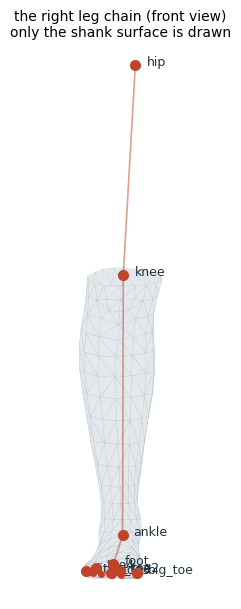

In [3]:
W_ = np.load(BODY, allow_pickle=True).item()["weights"][LEG_VERTS]
print(f"{'name':>15} {'joint':>6} {'pose numbers':>13} {'verts it owns':>15}   what it is")
for name, j in JOINTS.items():
    what = DESC.get(name, "")
    span = f"{j * 3}-{j * 3 + 2}"
    print(f"{name:>15} {j:6d} {span:>13} {int((W_[:, j] > 0.5).sum()):15d}   {what}")
owned = int((W_[:, list(JOINTS.values())] > 0.5).sum())
print(f"\n{owned} of {len(LEG_VERTS)} cut-out vertices are dominated by one of these joints.")
print("The toe joints dominate none -- they are skinned softly, so they move skin")
print("without owning it. Every other joint in the body leaves this piece alone.")

fig, ax = plt.subplots(figsize=(4.4, 7.2))
order = np.argsort(NEUTRAL[FACES][:, :, 2].mean(axis=1))
ax.add_collection(PolyCollection([NEUTRAL[FACES][:, :, [0, 1]][i] for i in order],
                                 facecolors="#E2E8EC", edgecolors="#00000018", linewidths=.25))
for name, j in JOINTS.items():
    tip = name.endswith("_tip")
    ax.plot(NEUTRAL_J[j, 0], NEUTRAL_J[j, 1], "o", ms=4 if tip else 7,
            color="#C0442A", zorder=5)
    if not tip:
        ax.annotate(name, (NEUTRAL_J[j, 0], NEUTRAL_J[j, 1]), textcoords="offset points",
                    xytext=(8, 0), fontsize=9, color="#22333F")
ax.plot(NEUTRAL_J[[2, 5, 8, 11], 0], NEUTRAL_J[[2, 5, 8, 11], 1],
        "-", lw=1.2, color="#C0442A", alpha=.5, zorder=4)

xs = np.concatenate([NEUTRAL[:, 0], NEUTRAL_J[list(JOINTS.values()), 0]])
ys = np.concatenate([NEUTRAL[:, 1], NEUTRAL_J[list(JOINTS.values()), 1]])
mx, my = 0.35 * np.ptp(xs), 0.04 * np.ptp(ys)
ax.set_xlim(xs.min() - mx, xs.max() + mx)
ax.set_ylim(ys.min() - my, ys.max() + my)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("the right leg chain (front view)\nonly the shank surface is drawn", fontsize=10)
plt.show()

## 4 — What the three axes of a joint do

Same idea as the foot notebook, but the probe point is the middle of the ankle rim, since
that is the end of the shank that actually travels.

In [4]:
# The cut-out reaches past the ankle now, so the most travelled point is the toe tip.
TOE_TIP = int(np.argmax(NEUTRAL[:, 2]))     # furthest forward vertex
HEEL    = int(np.argmin(NEUTRAL[:, 2]))     # furthest back

def what_does_axis_do(joint, degrees=20, probe=None):
    where = TOE_TIP if probe is None else probe
    base = NEUTRAL[where]
    label = "toe tip" if where == TOE_TIP else ("heel" if where == HEEL else f"vertex {where}")
    print(f"'{joint}' bent {degrees} deg on each axis -- where the {label} goes:")
    for axis in AXES:
        V, _ = leg(**{f"{joint}_{axis}": degrees})
        d = (V[where] - base) * UNIT_MM
        print(f"   {axis:5s}  outward {d[0]:+7.1f} mm   up {d[1]:+7.1f} mm   forward {d[2]:+7.1f} mm"
              f"   |  {AXIS_MEANING[axis]}")

what_does_axis_do("knee")
print()
what_does_axis_do("ankle")
print()
what_does_axis_do("hip")
print()
what_does_axis_do("big_toe", degrees=35)

print("\nA limb turns about its OWN axes, so what 'pitch' means depends on which way")
print("the limb points. The shank hangs down Y, so pitch swings it forward and back.")

'knee' bent 20 deg on each axis -- where the toe tip goes:
   pitch  outward    +0.0 mm   up   -31.3 mm   forward  -171.0 mm   |  bend forward/back -- knee (+) folds the heel back
   yaw    outward   +58.8 mm   up    -0.0 mm   forward   -15.2 mm   |  twist about the long axis
   roll   outward  +159.6 mm   up   +33.0 mm   forward    +0.0 mm   |  swing sideways -- (+) moves the shank outward

'ankle' bent 20 deg on each axis -- where the toe tip goes:


   pitch  outward    +0.1 mm   up   -71.7 mm   forward   -32.6 mm   |  bend forward/back -- knee (+) folds the heel back
   yaw    outward   +74.1 mm   up    -0.0 mm   forward   -18.5 mm   |  twist about the long axis
   roll   outward   +17.7 mm   up    +8.6 mm   forward    +1.1 mm   |  swing sideways -- (+) moves the shank outward

'hip' bent 20 deg on each axis -- where the toe tip goes:
   pitch  outward    +0.0 mm   up    -2.7 mm   forward  -283.8 mm   |  bend forward/back -- knee (+) folds the heel back
   yaw    outward   +51.5 mm   up    -0.0 mm   forward    -7.1 mm   |  twist about the long axis
   roll   outward  +275.1 mm   up   +46.6 mm   forward    +0.0 mm   |  swing sideways -- (+) moves the shank outward

'big_toe' bent 35 deg on each axis -- where the toe tip goes:
   pitch  outward    +0.2 mm   up   -10.6 mm   forward    -1.4 mm   |  bend forward/back -- knee (+) folds the heel back
   yaw    outward   +11.2 mm   up    -0.1 mm   forward    -0.6 mm   |  twist about the 

## 5 — Play with it

Every joint the cut-out responds to now has sliders: the knee, ankle and hip on all three
axes, and each toe on pitch. The toes are laid out the same way as the shape sliders --
knuckles down the left, tips down the right.

*all toes together* links the five knuckles, which is what you want for a push-off or a curl.

The 3D view keeps whatever camera angle you set with the mouse, so spin it once to a view you
like and then explore.

The betas move the **whole body**, so a beta that makes the person taller makes this shank
longer. That is the honest behaviour, not a bug.

In [5]:
import ipywidgets as W
from IPython.display import display

def explorer():
    style = {"description_width": "118px"}
    lay   = W.Layout(width="315px")
    mk = lambda d, lo, hi, st=1.0: W.FloatSlider(value=0, min=lo, max=hi, step=st, description=d,
                                                 continuous_update=False, style=style,
                                                 layout=lay, readout_format=".0f")
    toe_style = {"description_width": "112px"}
    toe_lay   = W.Layout(width="300px")
    mk_toe = lambda d: W.FloatSlider(value=0, min=-60, max=60, step=1, description=d,
                                     continuous_update=False, style=toe_style,
                                     layout=toe_lay, readout_format=".0f")

    # every joint gets its own dict of {axis: slider}, so presets and the pose
    # readout work the same way no matter which joint they touch
    groups = {
        "knee":  {a: mk(f"knee {a}",  -20, 140 if a == "pitch" else 40) for a in AXES},
        "ankle": {a: mk(f"ankle {a}", -40, 60) for a in AXES},
        "hip":   {a: mk(f"hip {a}",   -40, 100) for a in AXES},
    }
    TIPS = tuple(t + "_tip" for t in TOE_BASES)
    for t in TOE_BASES + TIPS:
        groups[t] = {"pitch": mk_toe(t.replace("_", " "))}

    all_toes = W.Checkbox(value=False, description="all toes together",
                          indent=False, layout=W.Layout(width="200px"))
    betas = [W.FloatSlider(value=0, min=-5, max=5, step=0.1, description=BETA_LABELS[i],
                           continuous_update=False, style={"description_width": "200px"},
                           layout=W.Layout(width="410px")) for i in range(6)]
    preset = W.Dropdown(options=["-"] + list(RECIPES), value="-", description="preset",
                        style=style, layout=lay)
    reset  = W.Button(description="reset", icon="undo")
    out    = W.Output()
    sliders = [s for group in groups.values() for s in group.values()]
    fig = make_view(NEUTRAL)
    guard = {"on": False}

    def kwargs():
        return {f"{joint}_{a}": s.value
                for joint, group in groups.items()
                for a, s in group.items() if s.value}

    def beta_dict():
        return {i: s.value for i, s in enumerate(betas) if s.value}

    def redraw(_=None):
        if guard["on"]:
            return
        kw, b = kwargs(), beta_dict()
        V, Jt = leg(betas=b or None, **kw)
        update_view(fig, V)
        parts = ([f"betas={b}"] if b else []) + [f"{k}={v:g}" for k, v in sorted(kw.items())]
        with out:
            out.clear_output(wait=True)
            print("leg(" + ", ".join(parts) + ")")
            report(V, "current", Jt)

    def on_toe_base(change):
        """With 'all toes together' on, one knuckle drives all five."""
        if guard["on"] or not all_toes.value:
            return
        guard["on"] = True
        for t in TOE_BASES:
            groups[t]["pitch"].value = change["new"]
        guard["on"] = False
        redraw()

    def set_all(pose):
        guard["on"] = True
        for s in sliders:
            s.value = 0
        for k, v in pose.items():
            joint, _, a = k.rpartition("_")
            if joint in groups and a in groups[joint]:
                groups[joint][a].value = v
            else:
                print(f"note: preset key {k!r} has no slider")
        guard["on"] = False

    def on_preset(_):
        if preset.value == "-":
            return
        set_all(RECIPES[preset.value])
        redraw()

    def on_reset(_):
        preset.unobserve(on_preset, names="value")
        preset.value = "-"
        preset.observe(on_preset, names="value")
        guard["on"] = True
        for s in sliders + betas:
            s.value = 0
        all_toes.value = False
        guard["on"] = False
        redraw()

    for s in sliders + betas:
        s.observe(redraw, names="value")
    for t in TOE_BASES:
        groups[t]["pitch"].observe(on_toe_base, names="value")
    preset.observe(on_preset, names="value")
    reset.on_click(on_reset)

    row = lambda joint: W.HBox(list(groups[joint].values()))
    controls = W.VBox([
        W.HTML("<b>the joint that matters &mdash; the knee</b>"),
        row("knee"),
        W.HTML("<b>ankle &mdash; rotates the foot and the skin above it</b>"),
        row("ankle"),
        W.HTML("<b>hip &mdash; moves the whole piece without reshaping it</b>"),
        row("hip"),
        W.HBox([W.HTML("<b>toes &mdash; knuckles left, tips right</b>"), all_toes]),
        W.HBox([W.VBox([groups[t]["pitch"] for t in TOE_BASES]),
                W.VBox([groups[t]["pitch"] for t in TIPS])]),
        W.HTML("<b>shape &mdash; whole-body betas</b>"),
        W.HBox([W.VBox(betas[:3]), W.VBox(betas[3:])]),
        W.HBox([preset, reset]),
    ])
    display(W.VBox([controls, fig, out]))
    redraw()

explorer()

## 6 — Which parameters give which pose

The recipes from the kit, measured. `knee` is the angle at the knee joint: 180 degrees is a
straight leg.

In [6]:
print(f"{'pose':26s} {'shank':>8} {'calf':>8} {'ankle':>8} {'knee':>7} {'stretch':>8}   parameters")
for name, kw in RECIPES.items():
    V, Jt = leg(**kw)
    _last_joints[0] = Jt
    m = measure(V)
    print(f"{name:26s} {m['shank_length_mm']:8.1f} {m['calf_girth_mm']:8.1f} "
          f"{m['ankle_girth_mm']:8.1f} {m['knee_angle_deg']:7.1f} {m['stretch_p99']:8.2f}   "
          + (", ".join(f"{k}={v:g}" for k, v in kw.items()) or "everything 0"))

pose                          shank     calf    ankle    knee  stretch   parameters
standing                      417.7    352.1    230.0   176.3     1.00   everything 0
knee bent 30                  417.7    353.4    230.0   147.8     1.19   knee_pitch=30
knee bent 90 (sitting)        417.7    357.7    230.0    88.0     1.48   knee_pitch=90
deep squat                    417.7    359.7    230.0    68.0     1.53   hip_pitch=85, knee_pitch=110
leg swung back                417.7    352.1    230.0   176.3     1.00   hip_pitch=30
toes pointed                  417.7    351.9    226.5   176.3     1.25   ankle_pitch=40
foot pulled up                417.7    352.1    230.6   176.3     1.09   ankle_pitch=-25
knee turned out               417.7    354.0    230.0   151.9     1.10   knee_roll=25
toes curled under             417.7    352.1    230.0   176.3     1.14   big_toe_pitch=35, toe2_pitch=35, toe3_pitch=35, toe4_pitch=35, little_toe_pitch=35
push-off                      417.7    352.0    2

## 7 — What the betas do to the shank

These are whole-body shape parameters, so read them as "this kind of person" rather than
"this kind of leg". Beta 0 is overall size, which is why it moves everything at once.

In [7]:
print(f"{'':6} {'shank':>9} {'calf':>9} {'ankle':>9} {'knee g':>9}   what it mostly does")
print(f"{'':6} {'mm':>9} {'mm':>9} {'mm':>9} {'mm':>9}")
print(f"{'base':6} {_BASE_DIMS[0]:9.1f} {_BASE_DIMS[1]:9.1f} {_BASE_DIMS[2]:9.1f} {_BASE_DIMS[3]:9.1f}")
for i in range(10):
    d = _dims_mm(leg(betas={i: 2.0})[0]) - _BASE_DIMS
    lab = beta_label(i).split("\u2014")[1].strip()
    print(f"b{i:<5} {d[0]:+9.1f} {d[1]:+9.1f} {d[2]:+9.1f} {d[3]:+9.1f}   {lab}")
print("\n(each row is that beta set to +2, everything else 0; numbers are the change from base)")

raw = np.load(BODY, allow_pickle=True).item()
S = np.asarray(raw["shapedirs"])[LEG_VERTS]          # only the shank rows
reach = np.linalg.norm(S, axis=1).max(axis=0) * UNIT_MM
print(f"\nfarthest a single shank vertex moves per 1.0 of each beta:")
for i in range(8):
    print(f"   beta {i}: {reach[i]:5.2f} mm")
print(f"   ...")
print(f"   beta 50: {reach[50]:5.2f} mm     beta 99: {reach[99]:5.2f} mm")
print(f"\nfirst 10 betas carry {100*reach[:10].sum()/reach.sum():.0f}% of the total reach, "
      f"first 50 carry {100*reach[:50].sum()/reach.sum():.0f}%.")

           shank      calf     ankle    knee g   what it mostly does
              mm        mm        mm        mm
base       417.7     352.1     230.0     367.5
b0         +47.3     +26.0     +13.6     +27.6   longer / shorter shank
b1          +1.9     +32.8     +21.4     +31.0   thicker / thinner calf
b2          -8.7     +25.7     +15.3     +26.4   thicker / thinner knee
b3          +8.5      -5.1      -2.4      -2.8   longer / shorter shank
b4          +4.9      +1.0      +4.2      +4.6   longer / shorter shank
b5          -2.3      -0.9      -3.9      -0.6   thicker / thinner ankle
b6          +9.0      -2.0      +1.0      +3.1   longer / shorter shank
b7          +0.5     +18.2      +8.5     +11.0   thicker / thinner calf
b8          -1.8     +11.5      +4.3     +12.1   thicker / thinner knee
b9          -1.0      +0.5      -0.7      +2.4   thicker / thinner knee

(each row is that beta set to +2, everything else 0; numbers are the change from base)

farthest a single shank ver

## 8 — The girth profile

The single most useful measurement for a boot shaft: how thick the leg is at each height.
This is the curve a shaft has to clear.

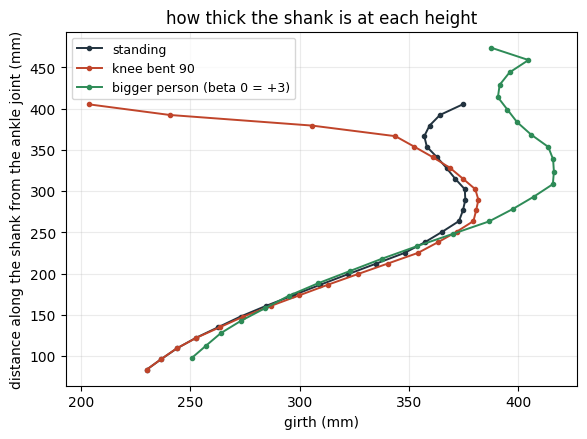

neutral shank: 417.7 mm, knee joint to ankle joint
  ankle   230.0 mm   (20% up the shank)
  calf    352.1 mm   (55% up)
  knee    367.5 mm   (95% up)
  widest  376.1 mm at 293 mm up

The lowest 20% is skipped: the cut-out includes the whole foot, and a
plane down there slices the ankle and heel rather than the shank.
Every girth is an exact triangle-plane intersection, not a bin of vertices --
453 vertices is far too coarse for binning to be trustworthy.


In [8]:
fig, ax = plt.subplots(figsize=(6.6, 4.6))
CASES = [("standing",                    {},                   None,      "#22333F"),
         ("knee bent 90",                {"knee_pitch": 90},   None,      "#C0442A"),
         ("bigger person (beta 0 = +3)",  {},                  {0: 3.0},   "#2E8B57")]
for name, kw, b, colour in CASES:
    V, Jt = leg(betas=b, **kw)                       # keep this pose's own joints
    g = girth_profile(V, slices=26, joints=Jt)
    ax.plot(g[:, 1], g[:, 0], "-o", ms=3, lw=1.4, color=colour, label=name)
ax.set_xlabel("girth (mm)")
ax.set_ylabel("distance along the shank from the ankle joint (mm)")
ax.set_title("how thick the shank is at each height")
ax.grid(alpha=.25); ax.legend(fontsize=9)
plt.show()

V, Jt = leg()
m = measure(V, Jt)
print(f"neutral shank: {m['shank_length_mm']:.1f} mm, knee joint to ankle joint")
print(f"  ankle  {m['ankle_girth_mm']:6.1f} mm   ({HEEL_SKIP:.0%} up the shank)")
print(f"  calf   {m['calf_girth_mm']:6.1f} mm   (55% up)")
print(f"  knee   {m['knee_girth_mm']:6.1f} mm   (95% up)")
print(f"  widest {m['max_girth_mm']:6.1f} mm at {m['max_girth_at_mm']:.0f} mm up")
print(f"\nThe lowest {HEEL_SKIP:.0%} is skipped: the cut-out includes the whole foot, and a")
print("plane down there slices the ankle and heel rather than the shank.")
print(f"Every girth is an exact triangle-plane intersection, not a bin of vertices --")
print(f"{len(LEG_VERTS)} vertices is far too coarse for binning to be trustworthy.")

## 9 — Export

In [9]:
from pathlib import Path

def export(V, name, out=f"{REPO}/output/supr_explorer"):
    """Write the current shank as PLY and OBJ, same folder as the other explorer output."""
    Path(out).mkdir(parents=True, exist_ok=True)
    p = Path(out) / f"{name}.ply"
    with open(p, "w") as f:
        f.write(f"ply\nformat ascii 1.0\nelement vertex {len(V)}\n")
        f.write("property float x\nproperty float y\nproperty float z\n")
        f.write(f"element face {len(FACES)}\nproperty list uchar int vertex_indices\n")
        f.write("end_header\n")
        for v in V:
            f.write(f"{v[0]:.6f} {v[1]:.6f} {v[2]:.6f}\n")
        for t in FACES:
            f.write(f"3 {t[0]} {t[1]} {t[2]}\n")
    o = Path(out) / f"{name}.obj"
    with open(o, "w") as f:
        for v in V:
            f.write(f"v {v[0]:.6f} {v[1]:.6f} {v[2]:.6f}\n")
        for t in FACES:
            f.write(f"f {t[0]+1} {t[1]+1} {t[2]+1}\n")
    print(f"wrote {p}\n      {o}")
    return p, o

# export(leg(knee_pitch=90)[0], "shank_knee90")

## 10 — Scratch

Yours. `leg(...)`, `report(...)`, `show(...)`, `make_view(...)`, `girth_profile(...)` are all
loaded.